## Import Packages 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import json

## Load Dataset

In [2]:
data_path = '../raw_data/First Dataset.xlsx'
raw_df = pd.read_excel(data_path)

## Summary & Overview

A quick peek of first records and statistical measures of our dataset.

In [3]:
raw_df.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19.0,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.0,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,F,31.0,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58.0,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,M,28.0,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [4]:
raw_df.describe()

,customer_id,age,purchase_count,avg_order_value,total_spending,last_purchase_days,returned_items,satisfaction_score
count,61.000000,60.000000,61.000000,61.000000,60.000000,61.000000,61.000000,61.00000
mean,1030.229508,45.200000,17.606557,211.435738,3749.667333,196.934426,4.196721,3.00000
std,17.446483,19.167239,10.214824,130.113726,4262.248522,97.892436,2.663454,1.42595
min,1001.000000,19.000000,0.000000,27.630000,0.000000,3.000000,0.000000,1.00000
25%,1015.000000,31.750000,11.000000,108.190000,1167.035000,132.000000,2.000000,2.00000
50%,1030.000000,45.000000,17.000000,161.330000,2188.865000,201.000000,4.000000,3.00000
75%,1045.000000,58.000000,26.000000,323.320000,4692.150000,273.000000,7.000000,4.00000
max,1060.000000,145.000000,35.000000,449.810000,25000.000000,365.000000,8.000000,5.00000


## Assess Data Quality

### Incorrect data types

A glance over data types to check whether column types were automatically infered correctly or not.

In [5]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         61 non-null     int64  
 1   first_name          61 non-null     str    
 2   gender              61 non-null     str    
 3   age                 60 non-null     float64
 4   city                61 non-null     str    
 5   province            61 non-null     str    
 6   signup_date         61 non-null     str    
 7   membership_tier     61 non-null     str    
 8   purchase_count      61 non-null     int64  
 9   avg_order_value     61 non-null     float64
 10  total_spending      60 non-null     float64
 11  last_purchase_days  61 non-null     int64  
 12  payment_method      61 non-null     str    
 13  device              61 non-null     str    
 14  discount_used       61 non-null     str    
 15  returned_items      61 non-null     int64  
 16  satisfaction_score  6

### Format consistency in categorical columns

Here we check for spelling consistency of categorical columns.

In [6]:
cat_col = ['first_name', 'gender', 'city', 'province', 'membership_tier', 'payment_method', 'device', 'discount_used']
raw_df[cat_col].nunique()

first_name         12
gender              2
city                8
province            8
membership_tier     4
payment_method      3
device              3
discount_used       2
dtype: int64

In [7]:
column_unique_values = {col:raw_df[col].unique().tolist() for col in cat_col}
print(json.dumps(column_unique_values, indent=4))

{
    "first_name": [
        "Reza",
        "Sina",
        "Parsa",
        "Kimia",
        "Amir",
        "Arash",
        "Neda",
        "Ali",
        "Mina",
        "Zahra",
        "Maryam",
        "Sara"
    ],
    "gender": [
        "F",
        "M"
    ],
    "city": [
        "Karaj",
        "Tehran",
        "Shiraz",
        "Mashhad",
        "Isfahan",
        "Rasht",
        "Tabriz",
        "Ahvaz"
    ],
    "province": [
        "Alborz",
        "Tehran",
        "Fars",
        "Khorasan",
        "Isfahan",
        "Gilan",
        "East Azerbaijan",
        "Khuzestan"
    ],
    "membership_tier": [
        "VIP",
        "Gold",
        "Silver",
        "Bronze"
    ],
    "payment_method": [
        "Card",
        "Online Wallet",
        "Cash"
    ],
    "device": [
        "Android",
        "Web",
        "iPhone"
    ],
    "discount_used": [
        "Yes",
        "No"
    ]
}


### Duplicate values

In [8]:
duplicates = raw_df[raw_df.duplicated()]
duplicates

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
60,1014,Reza,M,35.0,Tabriz,East Azerbaijan,2022-08-26,VIP,31,108.19,3353.89,97,Card,Android,No,5,4


### Missing values (percentage)

In [9]:
round((raw_df.isnull().sum() / raw_df.shape[0]) * 100, 2)

customer_id           0.00
first_name            0.00
gender                0.00
age                   1.64
city                  0.00
province              0.00
signup_date           0.00
membership_tier       0.00
purchase_count        0.00
avg_order_value       0.00
total_spending        1.64
last_purchase_days    0.00
payment_method        0.00
device                0.00
discount_used         0.00
returned_items        0.00
satisfaction_score    0.00
dtype: float64

### Outliers

#### Draw boxplot

First we need to define what columns we are intrested in handling their outliers. We ignore outliers for the rest as long as they are valid observations.

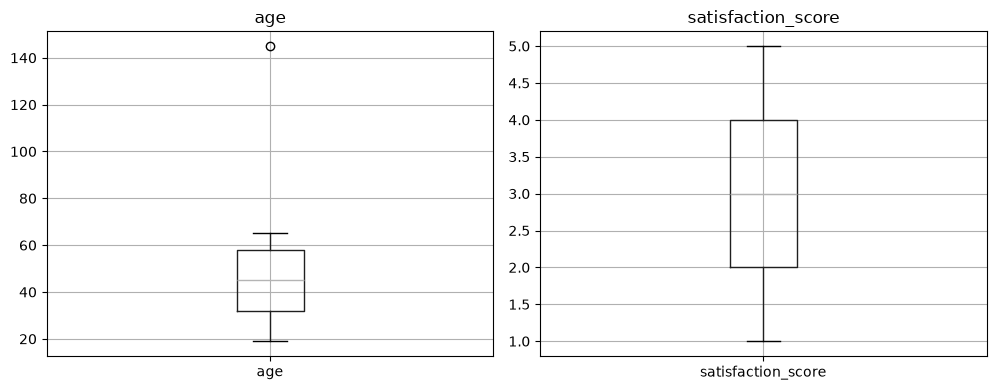

In [10]:
target_cols = ['age', 'satisfaction_score']
n = len(target_cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))

for ax, col in zip(axes.flat, target_cols):
    raw_df.boxplot(column=col, ax=ax)
    ax.set_title(col)

# Hide unused axes
for ax in axes.flat[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [11]:
mean_age = raw_df['age'].mean()
std_age = raw_df['age'].std()

lower_bound_age = mean_age - 2 * std_age
upper_bound_age = mean_age + 2 * std_age

outlier_mask = ~raw_df['age'].between(lower_bound_age, upper_bound_age) & ~raw_df['age'].isna()
outliers_age = raw_df[outlier_mask]
outliers_age.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
9,1010,Arash,F,145.0,Karaj,Alborz,2022-06-25,Silver,19,381.13,7241.47,276,Online Wallet,Android,No,7,1


### Integrity constraints

In [12]:
incosistency_mask = raw_df['purchase_count'] < raw_df['returned_items']
raw_df[incosistency_mask]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
7,1008,Reza,F,23.0,Rasht,Gilan,2024-10-03,VIP,3,389.58,1168.74,195,Online Wallet,iPhone,No,8,1
14,1015,Kimia,F,47.0,Ahvaz,Khuzestan,2021-07-24,Gold,3,307.91,923.73,55,Card,Android,Yes,8,4
23,1024,Sina,F,53.0,Ahvaz,Khuzestan,2025-01-27,Gold,0,63.67,0.00,298,Online Wallet,Android,No,2,1
28,1029,Ali,F,34.0,Tabriz,East Azerbaijan,2023-07-03,Gold,2,323.32,646.64,319,Cash,Web,Yes,4,5
36,1037,Zahra,M,42.0,Ahvaz,Khuzestan,2024-01-12,Gold,1,387.68,387.68,199,Cash,Web,Yes,7,2
55,1056,Kimia,M,61.0,Tabriz,East Azerbaijan,2025-01-25,Silver,1,449.81,449.81,240,Online Wallet,Web,No,4,2


The way we handle these depends on domain business.

## Clean Data

### De-duplicate data

In [13]:
cleaned_df = raw_df.drop_duplicates()

### Remove irrelevant data

In [14]:
#cleaned_df = cleaned_df.drop(columns=['customer_id'])

### Handle missing values

Inspecting a few records of **purchase_count** and **avg_count** columns shows that this equation might hold:

`total_spending = purchase_count * avg_count`

We first verify this on all records: 

In [15]:
equation_holds_mask = np.isclose(
    cleaned_df['total_spending'],
    cleaned_df['purchase_count'] * cleaned_df['avg_order_value'],
    rtol=1e-9,
    atol=1e-6
)
cleaned_df.loc[~equation_holds_mask, ['purchase_count', 'avg_order_value', 'total_spending']]

,purchase_count,avg_order_value,total_spending
29,26,156.89,25000.0
39,34,37.66,NaN


In [16]:
cleaned_df['age'] = cleaned_df['age'].fillna(cleaned_df['age'].median())

In [17]:
cleaned_df['total_spending'] = cleaned_df['total_spending'].fillna(cleaned_df['purchase_count'] * cleaned_df['avg_order_value'])
cleaned_df['total_spending'][39]

np.float64(1280.4399999999998)

### Convert data types

In [18]:
cat_dict = {col:'category' for col in cat_col}

age_discount_dict = {
    'age': int,
    'discount_used': bool
}

cleaned_df["discount_used"] = cleaned_df["discount_used"].map({"Yes": True, "No": False})

convert_dict = cat_dict | age_discount_dict

cleaned_df = cleaned_df.astype(convert_dict)

cleaned_df['signup_date'] = pd.to_datetime(cleaned_df['signup_date'])

# For memory save up
cleaned_df['satisfaction_score'] = cleaned_df['satisfaction_score'].astype('uint8')

# Clearly must be a positive value, uint covers more positive values range
cleaned_df['returned_items'] = cleaned_df['returned_items'].astype('uint64')

In [19]:
cleaned_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         60 non-null     int64         
 1   first_name          60 non-null     category      
 2   gender              60 non-null     category      
 3   age                 60 non-null     int64         
 4   city                60 non-null     category      
 5   province            60 non-null     category      
 6   signup_date         60 non-null     datetime64[us]
 7   membership_tier     60 non-null     category      
 8   purchase_count      60 non-null     int64         
 9   avg_order_value     60 non-null     float64       
 10  total_spending      60 non-null     float64       
 11  last_purchase_days  60 non-null     int64         
 12  payment_method      60 non-null     category      
 13  device              60 non-null     category      
 14  discoun

### Use a name database to automatically fix name genders

We utilize a seemingly relible open-source Persian name dataset from kaggle to correct gender for most of records. Then we manually correct the remaining records whose names didn't appear in the dataset. This could happen beacuse of different spelling of Persian names in English.  

In [20]:
name_gender_df = pd.read_csv("../raw_data/persian_names.csv") 

In [21]:
name_gender_df.info()
name_gender_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 8888 entries, 0 to 8887
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       8879 non-null   str    
 1   eng                          8879 non-null   str    
 2   count                        5633 non-null   float64
 3   pr_fa                        8879 non-null   str    
 4   abjad                        8879 non-null   float64
 5   pr_en                        8879 non-null   str    
 6   origin                       8878 non-null   str    
 7   civil_registration_approved  8879 non-null   str    
dtypes: float64(2), str(6)
memory usage: 555.6 KB


,gender,eng,count,pr_fa,abjad,pr_en,origin,civil_registration_approved
0,دختر,sana,76899.0,ثنا,551.0,sanā,عربی,تایید شده
1,دختر,samin,25615.0,ثمين,600.0,samin,عربی,تایید شده
2,دختر,sorayya,159065.0,ثريا,711.0,sorayyā,عربی,تایید شده
3,دختر,samar,2294.0,ثمر,740.0,samar,عربی,تایید شده
4,دختر,samina,2091.0,ثمينا,601.0,saminā,"فارسی , عربی",تایید شده


In [22]:
name_gender_df['gender'] = name_gender_df['gender'].replace({
    'دختر': 'F',
    'پسر': 'M'
})

In [23]:
name_gender_lookup = name_gender_df.set_index('eng')['gender'].to_dict()

In [24]:
cleaned_df['gender']  = (
    cleaned_df['first_name']
    .str.strip()
    .str.lower()
    .map(name_gender_lookup)
)

### Manually assign remaining genders

In [25]:
unknown_names_mask = cleaned_df['gender'].isna()
unknown_names = cleaned_df.loc[unknown_names_mask, 'first_name'].unique().tolist()
unknown_names

['Kimia']

In [26]:
name_gender_lookup['kimia'] = 'F'

In [27]:
cleaned_df.loc[unknown_names_mask, 'gender'] = (
    cleaned_df['first_name']
    .str.strip()
    .str.lower()
    .map(name_gender_lookup)
)

### Handle outliers

In [28]:
cleaned_df.loc[outlier_mask, 'age'] = cleaned_df['age'].median()

### Make columns an independent set

Columns **avg_order_value**, **total_spending**, and **purchase_count** form a dependent set of columns and consume additional memory. Depending on the use case, we can eliminate one of them if we do not need all three for analysis or if we have sufficient computational resources to derive it when needed.

By chossing to eliminate **avg_order_value** which can be calculated by **total_spending** and **purchase_count**, we can also handle that single record having 0 for **total_spending** and **purchase_count**

In [29]:
cleaned_df = cleaned_df.drop(columns=['avg_order_value'])

### Normalize data?

## Write output

In [30]:
out_dir = '../data/cleaned.xlsx'
cleaned_df.to_excel(out_dir)